In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.model_selection import train_test_split

In [32]:
df = pd.read_csv("loan_approval_data.csv")

In [33]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handle Missing value

In [34]:
categorial_cols = df.select_dtypes(["object"]).columns
numerical_cols = df.select_dtypes(["number"]).columns

In [35]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy ="most_frequent")
df[categorial_cols] = cat_imp.fit_transform(df[categorial_cols])

In [36]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# See How balanced our Classes

Text(0.5, 1.0, 'Loan approved or not ?')

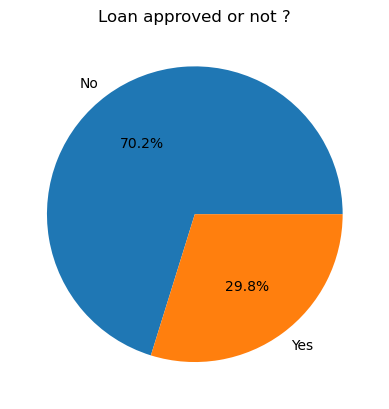

In [37]:
# See the Loan approved Ratio

loanratio = df["Loan_Approved"].value_counts()

plt.pie(
    loanratio,
    labels=["No","Yes"],
    autopct="%1.1f%%"
)
plt.title("Loan approved or not ?")

Text(0.5, 1.0, 'Loan approved or not ?')

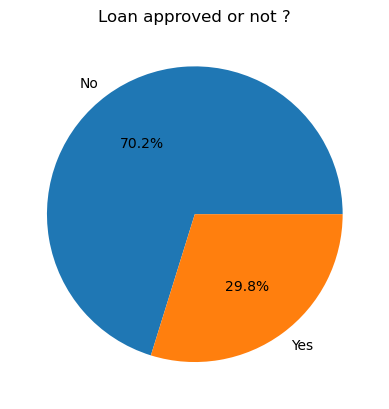

In [38]:
# See the Loan approved Ratio

loanratio = df["Loan_Approved"].value_counts()

plt.pie(
    loanratio,
    labels=["No","Yes"],
    autopct="%1.1f%%"
)
plt.title("Loan approved or not ?")

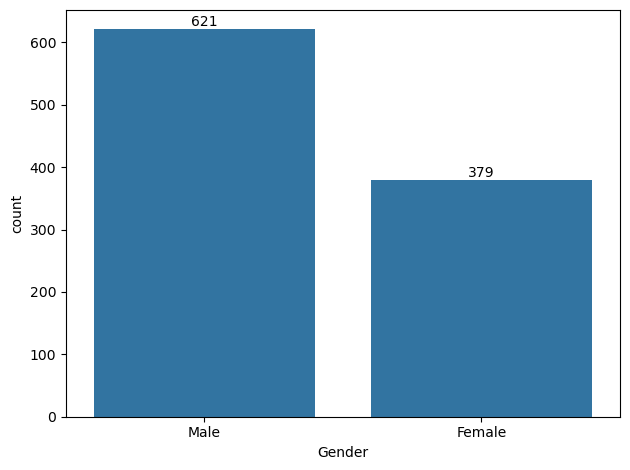

In [39]:
# How much poeple Are GenderWise

Gen_cnt = df["Gender"].value_counts()
ax = sns.barplot(Gen_cnt)
ax.bar_label(ax.containers[0])
plt.tight_layout()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

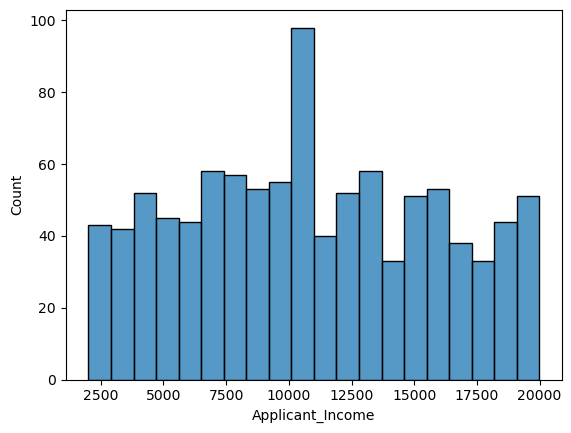

In [40]:
# See Applicant Income through Histogram

sns.histplot(data = df,x =df["Applicant_Income"],bins=20)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

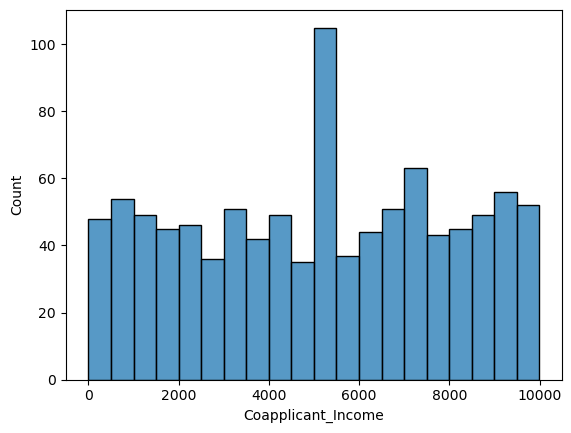

In [41]:
# See  Co-Applicant Income through Histogram

sns.histplot(data = df,x =df["Coapplicant_Income"],bins=20)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

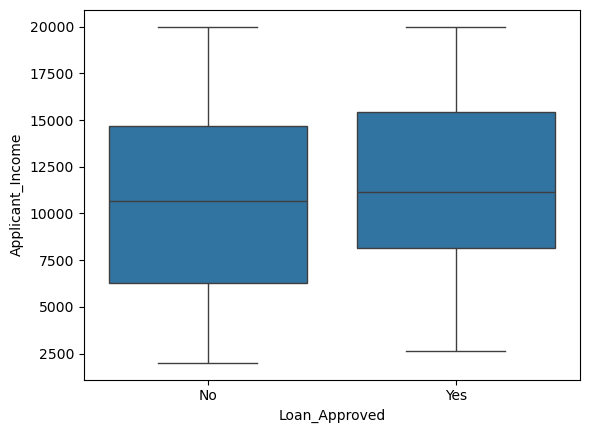

In [42]:
# See Anykind of outlier in our Data Throgh Boxplot

sns.boxplot(data = df, x =df["Loan_Approved"] , y=df["Applicant_Income"])

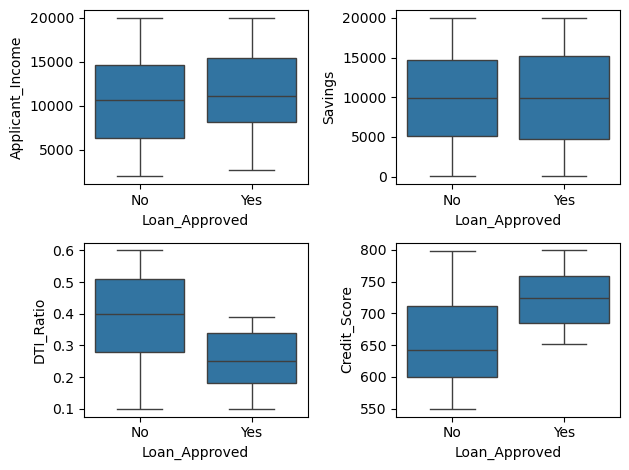

In [43]:
# See Anykind of outlier in our Data Throgh multiple Boxplot

fig , axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0],data = df, x =df["Loan_Approved"] , y=df["Applicant_Income"])
sns.boxplot(ax = axes[0,1],data = df, x =df["Loan_Approved"] , y=df["Savings"])
sns.boxplot(ax = axes[1,0],data = df, x =df["Loan_Approved"] , y=df["DTI_Ratio"])
sns.boxplot(ax = axes[1,1],data = df, x =df["Loan_Approved"] , y=df["Credit_Score"])
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

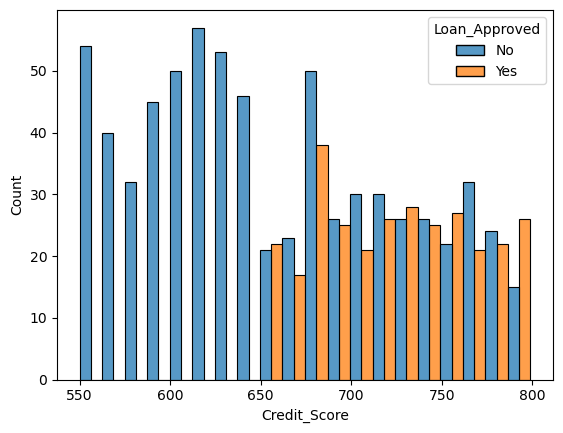

In [44]:
# See Approved loan with Credit Score

sns.histplot(data= df, x="Credit_Score",hue="Loan_Approved",bins = 20,multiple="dodge")

<Axes: xlabel='Applicant_Income', ylabel='Count'>

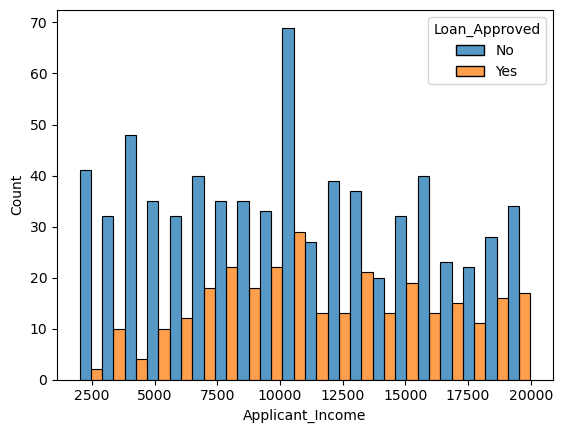

In [45]:
# See Approved loan with applicant Income
sns.histplot(data= df, x="Applicant_Income",hue="Loan_Approved",bins = 20,multiple="dodge")

# Removing Unwanted field that doesn't effect on Machine learning 

In [46]:
df = df.drop("Applicant_ID",axis=1)
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# Encoding the data

In [47]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
df["Education_Level"] = le.fit_transform(df["Education_Level"])

In [48]:
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])
encoded
encoded_df = pd.DataFrame(encoded,columns = ohe.get_feature_names_out(cols),index=df.index)
encoded_df
# ohe.get_feature_names_out(cols)

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Concate Both Data
 

In [52]:
# df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation with Heatmap

<Axes: >

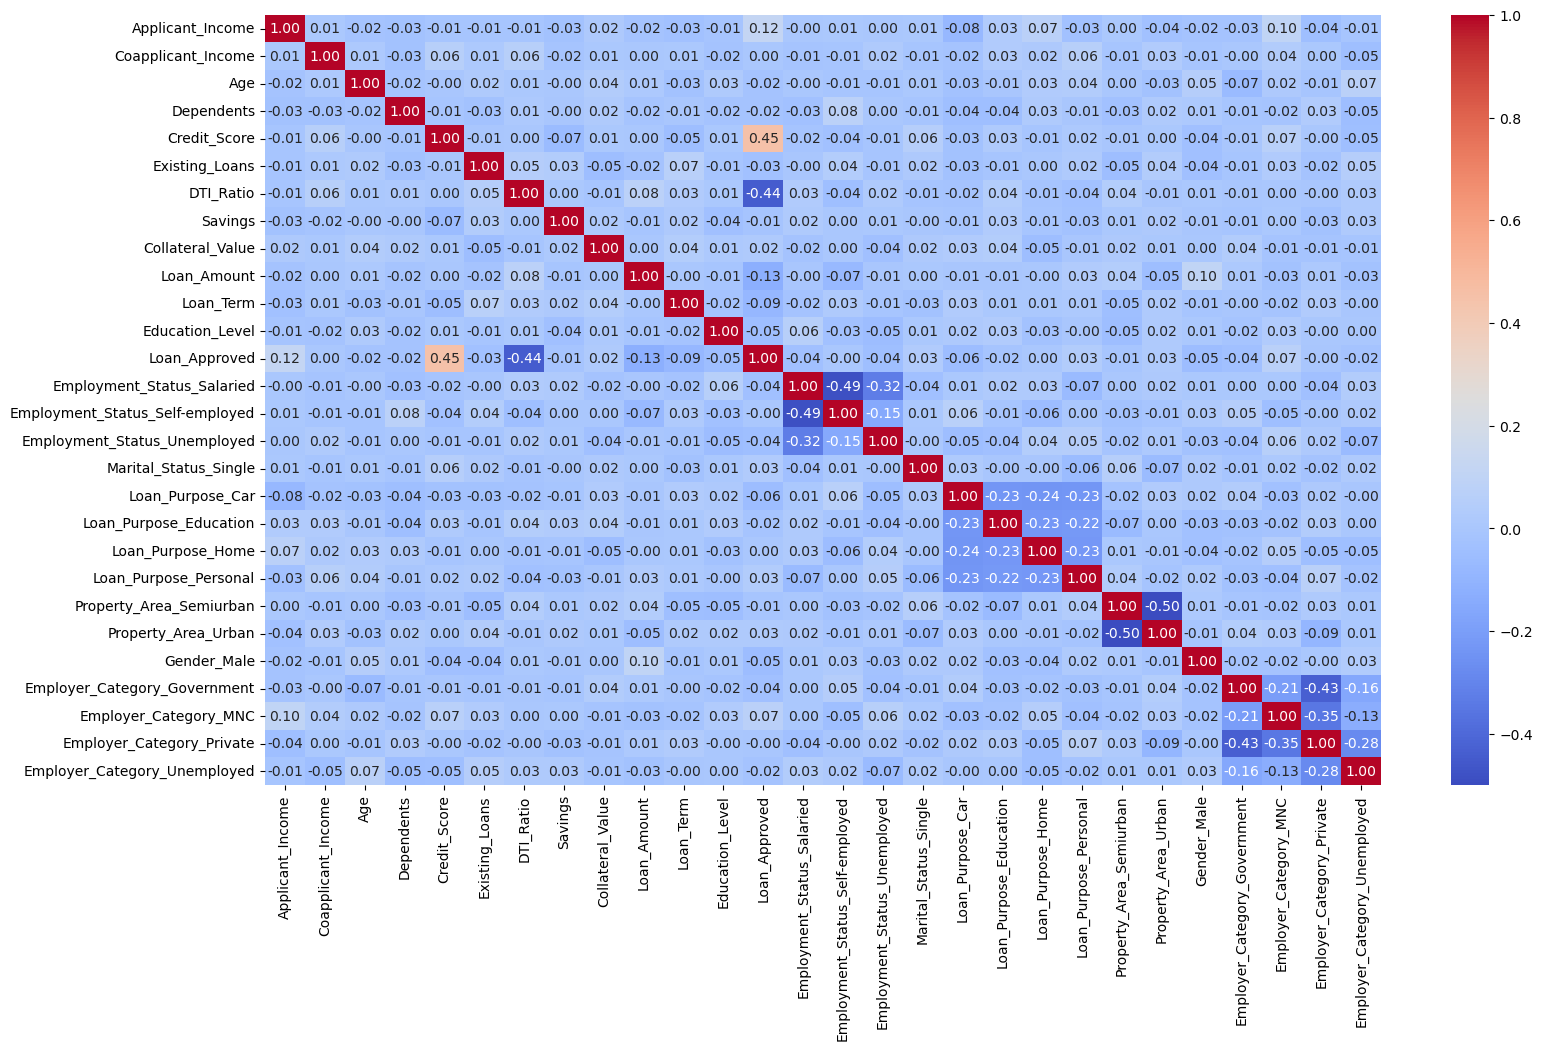

In [64]:
num_cols = df.select_dtypes("number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(18,10))
sns.heatmap(corr_matrix,
            fmt=".2f",
            annot=True,
            cmap="coolwarm")


# Train_test_split

In [66]:
X = df.drop(["Loan_Approved"],axis=1)
y = df["Loan_Approved"]

X_train,X_test , y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Evaluting 

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,recall_score,accuracy_score,f1_score,confusion_matrix    

In [119]:
# logistic regression

model = LogisticRegression()
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)

print("Logistic Model")
print("Precision score is :",precision_score(y_test,y_pred))
print("Recall score is :",recall_score(y_test,y_pred))
print("Accuracy score is :",accuracy_score(y_test,y_pred))
print("f1 score is :",f1_score(y_test,y_pred))
print("Confusion_matrix is :",confusion_matrix(y_test,y_pred))

Logistic Model
Precision score is : 0.7833333333333333
Recall score is : 0.7704918032786885
Accuracy score is : 0.865
f1 score is : 0.7768595041322314
Confusion_matrix is : [[126  13]
 [ 14  47]]


In [120]:
# Naive bayes
model1 = GaussianNB()
model1.fit(X_train_scaled,y_train)

y_pred = model1.predict(X_test_scaled)

print("Logistic Model")
print("Precision score is :",precision_score(y_test,y_pred))
print("Recall score is :",recall_score(y_test,y_pred))
print("Accuracy score is :",accuracy_score(y_test,y_pred))
print("f1 score is :",f1_score(y_test,y_pred))
print("Confusion_matrix is :",confusion_matrix(y_test,y_pred))

Logistic Model
Precision score is : 0.8035714285714286
Recall score is : 0.7377049180327869
Accuracy score is : 0.865
f1 score is : 0.7692307692307693
Confusion_matrix is : [[128  11]
 [ 16  45]]


In [121]:
# KNN 

model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train_scaled,y_train)

y_pred = model2.predict(X_test_scaled)

print("Logistic Model")
print("Precision score is :",precision_score(y_test,y_pred))
print("Recall score is :",recall_score(y_test,y_pred))
print("Accuracy score is :",accuracy_score(y_test,y_pred))
print("f1 score is :",f1_score(y_test,y_pred))
print("Confusion_matrix is :",confusion_matrix(y_test,y_pred))

Logistic Model
Precision score is : 0.6274509803921569
Recall score is : 0.5245901639344263
Accuracy score is : 0.76
f1 score is : 0.5714285714285714
Confusion_matrix is : [[120  19]
 [ 29  32]]


# Adding Features (Feature Scaling for Impove Model)

In [145]:
df["DTI_Ratio_sqr"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sqr"] = df["Credit_Score"] ** 2

X = df.drop(columns=["DTI_Ratio","Credit_Score","Loan_Approved"])
y = df["Loan_Approved"]

df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X_train,X_test , y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# df

In [146]:
# logistic regression

modellr = LogisticRegression()
modellr.fit(X_train_scaled,y_train)

y_pred = modellr.predict(X_test_scaled)

print("Logistic Model")
print("Precision score is :",precision_score(y_test,y_pred))
print("Recall score is :",recall_score(y_test,y_pred))
print("Accuracy score is :",accuracy_score(y_test,y_pred))
print("f1 score is :",f1_score(y_test,y_pred))
print("Confusion_matrix is :",confusion_matrix(y_test,y_pred))

Logistic Model
Precision score is : 0.7692307692307693
Recall score is : 0.819672131147541
Accuracy score is : 0.87
f1 score is : 0.7936507936507936
Confusion_matrix is : [[124  15]
 [ 11  50]]


In [143]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.66
Recall:  0.4342105263157895
F1 score:  0.5238095238095238
Accuracy:  0.76
CM:  [[157  17]
 [ 43  33]]


In [147]:
# Naive bayes
modelnv = GaussianNB()
modelnv.fit(X_train_scaled,y_train)

y_pred = modelnv.predict(X_test_scaled)

print("Logistic Model")
print("Precision score is :",precision_score(y_test,y_pred))
print("Recall score is :",recall_score(y_test,y_pred))
print("Accuracy score is :",accuracy_score(y_test,y_pred))
print("f1 score is :",f1_score(y_test,y_pred))
print("Confusion_matrix is :",confusion_matrix(y_test,y_pred))

Logistic Model
Precision score is : 0.8076923076923077
Recall score is : 0.6885245901639344
Accuracy score is : 0.855
f1 score is : 0.7433628318584071
Confusion_matrix is : [[129  10]
 [ 19  42]]
